# Trotter error optimization for 2D Ising model

This notebook:
1. Builds a small 2D Ising Hamiltonian for exact numerical verification
2. Sweeps Trotter order and num_divisions to find optimal parameters
3. Compares against commutator-bound theoretical step counts
4. Runs resource estimation (IQPE) for both theoretical and optimal points

In [11]:
import numpy as np
import scipy
import math
import pandas as pd
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import LatticeGraph, AlgorithmRef
from qdk_chemistry.utils.model_hamiltonians import create_ising_hamiltonian
from qdk_chemistry.utils import Logger
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.time_evolution.trotter import Trotter
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.time_evolution.trotter_error import trotter_steps_commutator

Logger.set_global_level(Logger.LogLevel.off)

nx = 2
lattice = LatticeGraph.chain(nx)
qubit_hamiltonian = create_ising_hamiltonian(lattice, j=1.0, h=0.5)

num_qubits = qubit_hamiltonian.num_qubits
print(f"Ising model: {nx} = {num_qubits} qubits (dim={2**num_qubits})")
print(f"Schatten norm: {qubit_hamiltonian.schatten_norm:.4f}")

# Exact ground state
H_mat = qubit_hamiltonian.to_matrix()
eigvals, eigvecs = np.linalg.eigh(H_mat)
ground_energy = eigvals[0]
ground_state = eigvecs[:, 0]
print(f"Ground state energy: {ground_energy:.6f}")

Ising model: 2 = 2 qubits (dim=4)
Schatten norm: 2.0000
Ground state energy: -1.414214


## Numerical Trotter error sweep

Sweep over Trotter orders 1, 2, 4 and QPE precision bits 6, 8, 10.
For each configuration, find the minimum `num_divisions` achieving the target accuracy.

In [12]:
_PAULI = {
    "I": np.eye(2, dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

def _pauli_matrix(pauli_map: dict[int, str], num_qubits: int) -> np.ndarray:
    """Build the full 2^n x 2^n matrix for a sparse Pauli map {qubit_idx: 'X'/'Y'/'Z'}."""
    mat = np.array([[1.0]], dtype=complex)
    for q in range(num_qubits - 1, -1, -1):
        mat = np.kron(mat, _PAULI[pauli_map.get(q, "I")])
    return mat

def numerical_error_sweep(hamiltonian, ground_state_vec, t=0.1, num_divisions=1, order=1):
    n_qubits = hamiltonian.num_qubits
    builder = Trotter(num_divisions=num_divisions, time=t, order=order)
    unitary = builder.run(hamiltonian)
    container = unitary.get_container()

    dim = 2**n_qubits
    u_step = np.eye(dim, dtype=complex)
    for term in container.step_terms:
        pauli_mat = _pauli_matrix(term.pauli_term, n_qubits)
        u_step = scipy.linalg.expm(-1j * term.angle * pauli_mat) @ u_step
    u_trot = np.linalg.matrix_power(u_step, container.step_reps)

    # Exact unitary
    hamiltonian_matrix = hamiltonian.to_matrix()
    u_exact = scipy.linalg.expm(-1j * t * hamiltonian_matrix)

    # State-specific error
    psi_trot = u_trot @ ground_state_vec
    psi_exact = u_exact @ ground_state_vec
    ground_state_error = np.linalg.norm(psi_trot - psi_exact)

    return ground_state_error

In [13]:
t_base = math.pi / qubit_hamiltonian.schatten_norm
target_accuracy = 1e-2
sweep_results = []
theoretical_params = []
optimal_params = []
max_num_divisions = 20_000
for order in [1, 2, 4, 8]:
    for num_phase_bit in range(6, 11, 2):
        scaled_t = t_base * 2**(num_phase_bit - 1)
        step = trotter_steps_commutator(qubit_hamiltonian, scaled_t, target_accuracy, order=order)
        theoretical_params.append({
            "order": order,
            "num_phase_bit": num_phase_bit,
            "t": t_base,
            "scaled_t": scaled_t,
            "num_divisions": step,
        })
        print(f"order={order}, num_phase_bit={num_phase_bit}: theoretical num_divisions={step}")
        for num_divisions in range(1, max_num_divisions, 20):
            ground_state_error = numerical_error_sweep(
                qubit_hamiltonian, ground_state,
                t=scaled_t, num_divisions=num_divisions, order=order,
            )
            sweep_results.append({
                "order": order,
                "num_phase_bit": num_phase_bit,
                "scaled_t": scaled_t,
                "num_divisions": num_divisions,
                "ground_state_error": ground_state_error,
            })
            if ground_state_error < target_accuracy:
                optimal_params.append({
                    "order": order,
                    "num_phase_bit": num_phase_bit,
                    "t": t_base,
                    "scaled_t": scaled_t,
                    "num_divisions": num_divisions,
                    "ground_state_error": ground_state_error,
                })
                print(f"  -> optimal num_divisions={num_divisions}, error={ground_state_error:.3e}")
                break
            elif num_divisions == max_num_divisions - 19:
                print(f"  -> did not reach target accuracy for order={order}, num_phase_bit={num_phase_bit} after {num_divisions} divisions, error={ground_state_error:.3e}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df

order=1, num_phase_bit=6: theoretical num_divisions=252662
  -> optimal num_divisions=3321, error=9.953e-03
order=1, num_phase_bit=8: theoretical num_divisions=4042590
  -> optimal num_divisions=15501, error=9.998e-03
order=1, num_phase_bit=10: theoretical num_divisions=64681440
  -> did not reach target accuracy for order=1, num_phase_bit=10 after 19981 divisions, error=1.534e-01
order=2, num_phase_bit=6: theoretical num_divisions=2520
  -> optimal num_divisions=1241, error=9.729e-03
order=2, num_phase_bit=8: theoretical num_divisions=20160
  -> optimal num_divisions=9801, error=9.973e-03
order=2, num_phase_bit=10: theoretical num_divisions=161277
  -> optimal num_divisions=3141, error=3.145e-03
order=4, num_phase_bit=6: theoretical num_divisions=1424
  -> optimal num_divisions=121, error=6.758e-03
order=4, num_phase_bit=8: theoretical num_divisions=8054
  -> optimal num_divisions=641, error=9.038e-03
order=4, num_phase_bit=10: theoretical num_divisions=45556
  -> optimal num_division

,order,num_phase_bit,scaled_t,num_divisions,ground_state_error
0,1,6,50.265482,1,1.667146
1,1,6,50.265482,21,1.658270
2,1,6,50.265482,41,1.111522
3,1,6,50.265482,61,1.472175
4,1,6,50.265482,81,1.854059
...,...,...,...,...,...
2869,4,10,804.247719,3481,0.010826
2870,4,10,804.247719,3501,0.010583
2871,4,10,804.247719,3521,0.010347
2872,4,10,804.247719,3541,0.010118


In [14]:
theoretical_df = pd.DataFrame(theoretical_params)
optimal_df = pd.DataFrame(optimal_params)
print("Theoretical step counts (commutator bound):")
display(theoretical_df)
print("\nOptimal step counts (numerical):")
display(optimal_df)

Theoretical step counts (commutator bound):


,order,num_phase_bit,t,scaled_t,num_divisions
0,1,6,1.570796,50.265482,252662
1,1,8,1.570796,201.061930,4042590
2,1,10,1.570796,804.247719,64681440
3,2,6,1.570796,50.265482,2520
4,2,8,1.570796,201.061930,20160
5,2,10,1.570796,804.247719,161277
6,4,6,1.570796,50.265482,1424
7,4,8,1.570796,201.061930,8054
8,4,10,1.570796,804.247719,45556



Optimal step counts (numerical):


,order,num_phase_bit,t,scaled_t,num_divisions,ground_state_error
0,1,6,1.570796,50.265482,3321,0.009953
1,1,8,1.570796,201.061930,15501,0.009998
2,2,6,1.570796,50.265482,1241,0.009729
3,2,8,1.570796,201.061930,9801,0.009973
4,2,10,1.570796,804.247719,3141,0.003145
5,4,6,1.570796,50.265482,121,0.006758
6,4,8,1.570796,201.061930,641,0.009038
7,4,10,1.570796,804.247719,3561,0.009894


## Resource estimation (IQPE)

Run logical resource estimation for both theoretical and numerically-optimal Trotter parameters.

In [15]:
from qdk_chemistry.algorithms.state_preparation import identity_state_prep


def run_trotter_estimate(qubit_ham, m_precision, trotter_order, num_divisions, evolution_time):
    unitary_builder = AlgorithmRef(
        "hamiltonian_unitary_builder", "trotter",
        time=evolution_time, order=trotter_order,
        power_strategy="rescale", num_divisions=num_divisions,
    )
    circuit_mapper = AlgorithmRef("controlled_circuit_mapper", "pauli_sequence")
    iqpe_circuit_builder = create(
        "qpe_circuit_builder",
        "qdk_iterative",
        num_bits=m_precision,
        unitary_builder=unitary_builder,
        controlled_circuit_mapper=circuit_mapper,
    )
    state_prep = identity_state_prep(num_qubits=qubit_ham.num_qubits)
    circuits = iqpe_circuit_builder.run(state_prep, qubit_ham)
    largest_circuit = circuits[0]
    result = largest_circuit.estimate()
    return result["logicalCounts"]


estimate_results = []

# Optimal parameters
for row in optimal_params:
    logical_estimate = run_trotter_estimate(
        qubit_hamiltonian,
        row["num_phase_bit"], row["order"], row["num_divisions"], row["scaled_t"],
    )
    estimate_results.append({
        "type": "optimal",
        "m_precision": row["num_phase_bit"],
        "trotter_order": row["order"],
        "num_divisions": row["num_divisions"],
        "evolution_time": row["scaled_t"],
        "numQubits": logical_estimate["numQubits"],
        "rotationCount": logical_estimate["rotationCount"],
        "rotationDepth": logical_estimate["rotationDepth"],
    })

# Theoretical parameters
for row in theoretical_params:
    logical_estimate = run_trotter_estimate(
        qubit_hamiltonian,
        row["num_phase_bit"], row["order"], row["num_divisions"], row["scaled_t"],
    )
    estimate_results.append({
        "type": "theoretical",
        "m_precision": row["num_phase_bit"],
        "trotter_order": row["order"],
        "num_divisions": row["num_divisions"],
        "evolution_time": row["scaled_t"],
        "numQubits": logical_estimate["numQubits"],
        "rotationCount": logical_estimate["rotationCount"],
        "rotationDepth": logical_estimate["rotationDepth"],
    })

estimate_df = pd.DataFrame(estimate_results)
estimate_df

,type,m_precision,trotter_order,num_divisions,evolution_time,numQubits,rotationCount,rotationDepth
0,optimal,6,1,3321,50.265482,3,19926,16605
1,optimal,8,1,15501,201.061930,3,93006,77505
2,optimal,6,2,1241,50.265482,3,12410,9928
3,optimal,8,2,9801,201.061930,3,98010,78408
4,optimal,10,2,3141,804.247719,3,31410,25128
5,optimal,6,4,121,50.265482,3,4114,3388
6,optimal,8,4,641,201.061930,3,21794,17948
7,optimal,10,4,3561,804.247719,3,121074,99708
8,theoretical,6,1,252662,50.265482,3,1515972,1263310
9,theoretical,8,1,4042590,201.061930,3,24255540,20212950


In [16]:
# Compare theoretical vs optimal: rotation count savings
comparison = estimate_df.pivot_table(
    index=["m_precision", "trotter_order"],
    columns="type",
    values=["num_divisions", "rotationCount", "rotationDepth"],
)
comparison

num_divisions             rotationCount  \
type                            optimal theoretical       optimal   
m_precision trotter_order                                           
6           1                    3321.0    252662.0       19926.0   
            2                    1241.0      2520.0       12410.0   
            4                     121.0      1424.0        4114.0   
8           1                   15501.0   4042590.0       93006.0   
            2                    9801.0     20160.0       98010.0   
            4                     641.0      8054.0       21794.0   
10          1                       NaN  64681440.0           NaN   
            2                    3141.0    161277.0       31410.0   
            4                    3561.0     45556.0      121074.0   

                                       rotationDepth               
type                       theoretical       optimal  theoretical  
m_precision trotter_order                                          
6           1                1515972.0       16605.0    1263310.0  
            2                  25200.0        9928.0      20160.0  
            4                  48416.0        3388.0      39872.0  
8           1               24255540.0       77505.0   20212950.0  
            2                 201600.0       78408.0     161280.0  
            4                 273836.0       17948.0     225512.0  
10          1              388088640.0           NaN  323407200.0  
            2                1612770.0       25128.0    1290216.0  
            4                1548904.0       99708.0    1275568.0

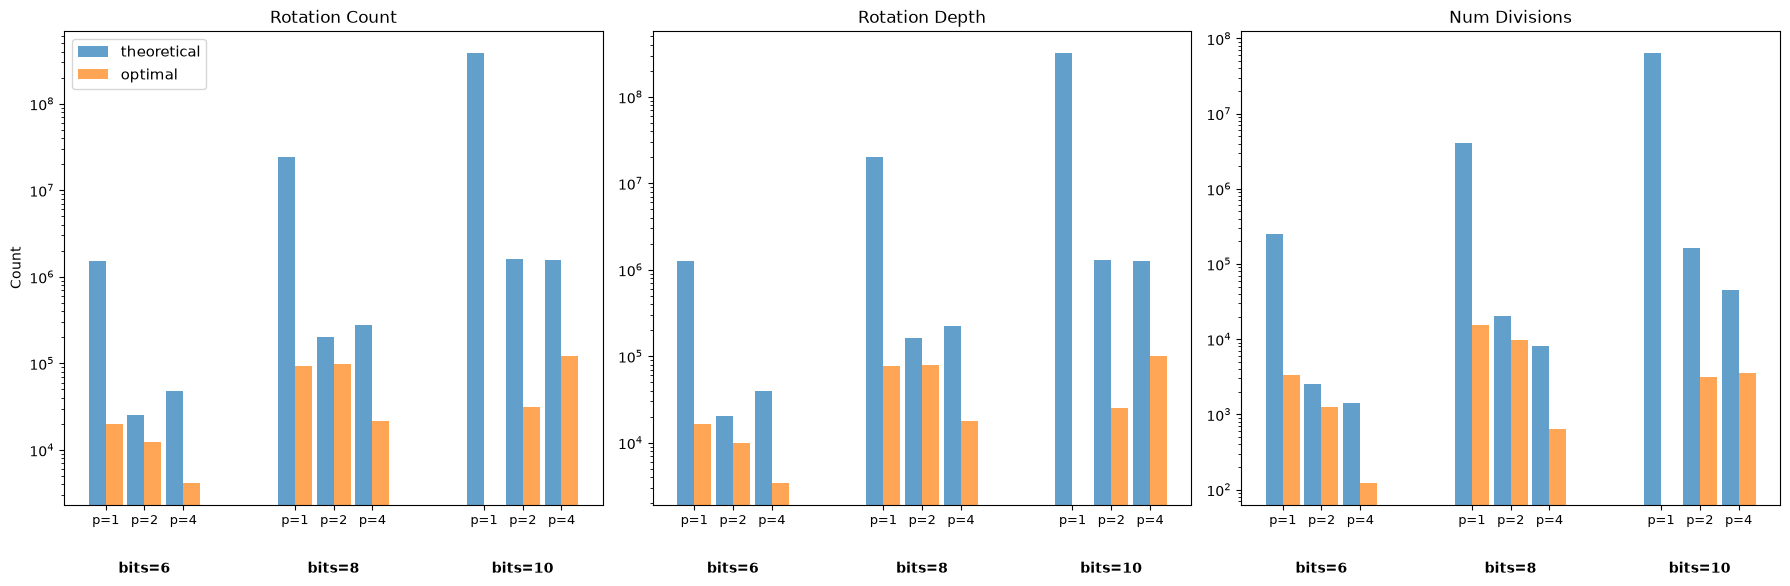

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ["rotationCount", "rotationDepth", "num_divisions"]
titles = ["Rotation Count", "Rotation Depth", "Num Divisions"]

phase_bits = sorted(estimate_df["m_precision"].unique())
orders = [1, 2, 4]
n_orders = len(orders)
bar_width = 0.35
group_gap = 1.5  # gap between phase_bit groups

# Build x positions: orders 1,2,4 side by side, grouped by phase_bits
x_ticks = []
x_labels = []
x_pos = 0
group_centers = []
for pb in phase_bits:
    group_start = x_pos
    for ord_val in orders:
        x_ticks.append(x_pos)
        x_labels.append(f"p={ord_val}")
        x_pos += 2 * bar_width + 0.1
    group_centers.append((group_start + x_pos - 2 * bar_width - 0.1) / 2)
    x_pos += group_gap

x_ticks = np.array(x_ticks)

for ax, metric, title in zip(axes, metrics, titles):
    theo_vals = []
    opt_vals = []
    for pb in phase_bits:
        for ord_val in orders:
            theo_row = estimate_df[(estimate_df["type"] == "theoretical") & (estimate_df["m_precision"] == pb) & (estimate_df["trotter_order"] == ord_val)]
            opt_row = estimate_df[(estimate_df["type"] == "optimal") & (estimate_df["m_precision"] == pb) & (estimate_df["trotter_order"] == ord_val)]
            theo_vals.append(theo_row[metric].values[0] if len(theo_row) else 0)
            opt_vals.append(opt_row[metric].values[0] if len(opt_row) else 0)

    ax.bar(x_ticks - bar_width / 2, theo_vals, bar_width, label="theoretical" if ax == axes[0] else "", color="C0", alpha=0.7)
    ax.bar(x_ticks + bar_width / 2, opt_vals, bar_width, label="optimal" if ax == axes[0] else "", color="C1", alpha=0.7)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=9)
    # Add phase_bit group labels
    for center, pb in zip(group_centers, phase_bits):
        ax.text(center, -0.12, f"bits={pb}", ha="center", va="top", fontsize=10, fontweight="bold",
                transform=ax.get_xaxis_transform())
    ax.set_title(title)
    ax.set_yscale("log")

axes[0].set_ylabel("Count")
axes[0].legend(fontsize=11)
fig.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()